It seems like the Green's function approach is working pretty well on the single atom case when comparing it to the results of perturbation theory, so it is worthwhile to add an extra atom and see if that still holds true.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu
import sympy as sym
from scipy import linalg
import time

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Results

In [3]:
# Define parameters
N = 2                                     # Number of atoms
Δ1s = [0, 0]                         # Detuning of each atom bottom transition (for now all zero)
δcs = [0, 0]                         # Detuning of each atom top transition (for now all zero)
κ = 1                                     # The loss rate of the cavity mode
γ10s = np.ones(N)                         # The decay rates of the atoms from |1> to |0> (all same for now)
γ21s = 0.05 * np.ones(N)                  # The decay rates of the atoms from |2> to |1> (all same for now)
g10s = 5 / np.sqrt(N) * np.ones(N)      # Coupling of |0>-|1> transition for each atom (all same for now)
g21s = 10 / np.sqrt(N) * np.ones(N)      # Coupling of |1>-|2> transition for each atom (all same for now)
λ = 1e-3                                  # Coupling of drive term to cavity mode

In [4]:
# Define operators for defining H
a = qu.destroy(2)
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])

# Define identity matrices over these spaces for convenience
Ic = qu.qeye(2)
Ia = qu.qeye(3)

In [5]:
# Define Hamiltonian using operators over the full basis
H = -1j*κ * qu.tensor([a.dag()*a, Ia, Ia]) - (Δ1s[0] + 1j*γ10s[0]) * qu.tensor([Ic, σ10.dag() * σ10, Ia])
H += - (Δ1s[1] + 1j*γ10s[1]) * qu.tensor([Ic, Ia, σ10.dag() * σ10])
H += -(δcs[0] + Δ1s[0] + 1j*γ21s[0]) * qu.tensor([Ic, σ21.dag() * σ21, Ia])
H += -(δcs[1] + Δ1s[1] + 1j*γ21s[1]) * qu.tensor([Ic, Ia, σ21.dag() * σ21])
H += g10s[0] * (qu.tensor([Ic, σ10.dag(), Ia]) + qu.tensor([Ic, σ10, Ia]))
H += g10s[1] * (qu.tensor([Ic, Ia, σ10.dag()]) + qu.tensor([Ic, Ia, σ10]))
H

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.        +0.j   3.53553391+0.j   0.        +0.j   3.53553391+0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j  ]
 [3.53553391+0.j   0.        -1.j   0.        +0.j   0.        +0.j
  3.53553391+0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j  ]
 [0.        +0.j   0.        +0.j   0.        -0.05j 0.        +0.j
  0.        +0.j   3.53553391+0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j


For clarity, this should be arranged along the diagonal as $|0,0,0\rangle\langle0,0,0|, |0,0,1\rangle\langle0,0,1|, \cdots, |1,2,2\rangle\langle,1,2,2|$.

In [6]:
# Define the interaction V
V = g21s[0] * (qu.tensor([a, σ21.dag(), Ia]) + qu.tensor([a.dag(), σ21, Ia]))
V += g21s[1] * (qu.tensor([a, Ia, σ21.dag()]) + qu.tensor([a.dag(), Ia, σ21]))

In [7]:
# Define the drive V
Vd = λ * (qu.tensor([a.dag(), Ia, Ia]) + qu.tensor([a, Ia, Ia]))

#### Perturbation Theory Calculation
For this, we need to create the block diagonal form of $H_u$ and $H_p$.  Here $H_p$ will include $V$ to match the setup in the Ningyuang paper.  The basis states that belong to $H_u$ are $|0,0,0\rangle, |0,0,1\rangle, |0,1,0\rangle,$ and $|0,1,1\rangle$.  The basis states belonging to $H_p$ are $|0,0,2\rangle, |0,1,2\rangle, |0,2,0\rangle, |0,2,1\rangle, |1,0,0\rangle, |1,0,1\rangle, |1,1,0\rangle,$ and $|1,1,1\rangle$.

In [8]:
# Define atom and cavity basis states
cav_bas = [qu.basis(2,i) for i in range(2)]
atom_bas = [qu.basis(3,i) for i in range(3)]

In [9]:
# Define basis for Hu
Hu_bas = [qu.tensor([cav_bas[0], atom_bas[i], atom_bas[j]]) for i in range(2) for j in range(2)]

# Create empty matrix for storing the matching matrix elements
Hu_mat = np.zeros((len(Hu_bas), len(Hu_bas)), dtype=complex)

# Get the matrix elements
for i in range(len(Hu_bas)):
    for j in range(len(Hu_bas)):
        Hu_mat[i][j] = Hu_bas[i].dag() * H * Hu_bas[j]

# Convert to qObj
Hu = qu.Qobj(Hu_mat)
Hu

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.        +0.j 3.53553391+0.j 3.53553391+0.j 0.        +0.j]
 [3.53553391+0.j 0.        -1.j 0.        +0.j 3.53553391+0.j]
 [3.53553391+0.j 0.        +0.j 0.        -1.j 3.53553391+0.j]
 [0.        +0.j 3.53553391+0.j 3.53553391+0.j 0.        -2.j]]

In [10]:
# Define basis for Hp
Hp_bas = [qu.tensor([cav_bas[0], atom_bas[i], atom_bas[2]]) for i in range(2)]
Hp_bas += [qu.tensor([cav_bas[0], atom_bas[2], atom_bas[i]]) for i in range(2)]
Hp_bas += [qu.tensor([cav_bas[1], atom_bas[i], atom_bas[j]]) for i in range(2) for j in range(2)]

# Create empty matrix for storing the matching matrix elements
Hp_mat = np.zeros((len(Hp_bas), len(Hp_bas)), dtype=complex)

# Get the matrix elements
for i in range(len(Hp_bas)):
    for j in range(len(Hp_bas)):
        Hp_mat[i][j] = Hp_bas[i].dag() * (H + V) * Hp_bas[j]

# Convert to qObj
Hp = qu.Qobj(Hp_mat)
Hp

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.        -0.05j 3.53553391+0.j   0.        +0.j   0.        +0.j
  0.        +0.j   7.07106781+0.j   0.        +0.j   0.        +0.j  ]
 [3.53553391+0.j   0.        -1.05j 0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   7.07106781+0.j  ]
 [0.        +0.j   0.        +0.j   0.        -0.05j 3.53553391+0.j
  0.        +0.j   0.        +0.j   7.07106781+0.j   0.        +0.j  ]
 [0.        +0.j   0.        +0.j   3.53553391+0.j   0.        -1.05j
  0.        +0.j   0.        +0.j   0.        +0.j   7.07106781+0.j  ]
 [0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        -1.j   3.53553391+0.j   3.53553391+0.j   0.        +0.j  ]
 [7.07106781+0.j   0.        +0.j   0.        +0.j   0.        +0.j
  3.53553391+0.j   0.        -2.j   0.        +0.j   3.53553391+0.j  ]
 [0.        +0.j   0.        +0.j   7.07106781+0.j   0.        +0.

Because $H_u$ and $H_p$ have different dimensions once we filter out the states that we don't particularly care about, we have to be more careful in how we go about calculating the result from perturbation theory.  More precisely, we need to consider how $V_d$ acts on the eigenstates of $H_u$ and what that looks like in the basis used to construct $H_p$.  In general, the eigenstates of $H_u$ can be written $|\epsilon_i\rangle = \sum_{n,m=0}^{1}\alpha_{n,m}|0,n,m\rangle$.  This means that $V_d|\epsilon_i\rangle = \sum_{n,m=0}^{1}\alpha_{n,m}|1,n,m\rangle$.  In the basis of $H_p$, this corresponds to $(0,0,0,0,\alpha_{0,0},\alpha_{0,1},\alpha_{1,0},\alpha_{1,1})$.

In [11]:
# Get the eigenstates of Hu
Hu_eigs = Hu.eigenstates()

# Calculate the vectors that we'll need for the perturbation theory results
vecs = [qu.Qobj([0, 0, 0, 0] + [_ for _ in Hu_eigs[1][i].full().T[0]]) for i in range(len(Hu_bas))]

# Also define the cavity mode vectors that we'll need
temp = [0 for i in range(len(Hp_bas))]
cav_vecs = []
for i in range(4,len(Hp_bas)):
    temp_copy = temp.copy()
    temp_copy[i] = 1
    cav_vecs.append(qu.Qobj(temp_copy))

In [12]:
# Define δL
δL = np.linspace(-50, 50, 1000)

In [13]:
# Define array for storing overlaps
pt_ovlps = np.zeros((len(vecs), len(cav_vecs), δL.shape[0]), dtype=complex)

# Loop over, calculate the perturbation theory result, and store overlap with cavity vector
for i in range(len(vecs)):
    for j in range(len(cav_vecs)):
        for k in range(δL.shape[0]):
            pt_ovlps[i][j][k] = cav_vecs[j].dag() * (δL[k] * qu.qeye(len(Hp_bas)) - Hp).inv() * vecs[i]

I have found in previous calculations that the only real way to compare these results to those of the Green's function approach is to look at the sum of the absolute value squares of the individual overlaps.  This is because there isn't really a convenient way to peel off the contributions from the other atom-cavity states in the perturbation theory results given how they're calculated.

In [14]:
# Calculate the totals
sum_abs_val_sq_pt = np.zeros(δL.shape[0], dtype=complex)
for i in range(len(vecs)):
    for j in range(len(cav_vecs)):
        sum_abs_val_sq_pt += np.abs(pt_ovlps[i][j]) ** 2

/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


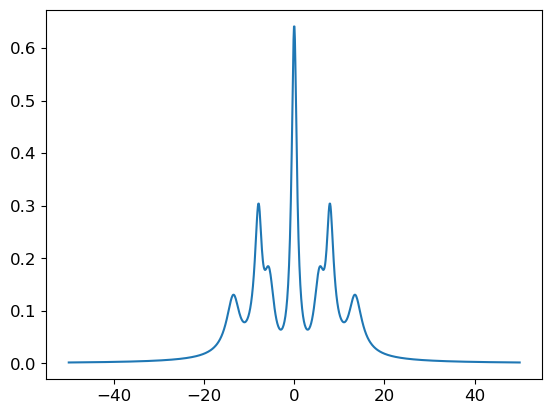

In [15]:
# Plot
plt.plot(δL, sum_abs_val_sq_pt)

#### Green's Function Approach Calculations

In [16]:
def exact_resolvent(z, H):
    return (z - H).inv()

In [17]:
# Define core Hamiltonian H0 basis
H0_bas = [qu.tensor([cav_bas[0], atom_bas[i], atom_bas[j]]) for i in range(3) for j in range(3)]
#H0_bas += [qu.tensor([cav_bas[0], atom_bas[i], atom_bas[2]]) for i in range(2)]
#H0_bas += [qu.tensor([cav_bas[0], atom_bas[2], atom_bas[i]]) for i in range(2)]
H0_bas += [qu.tensor([cav_bas[1], atom_bas[i], atom_bas[j]]) for i in range(2) for j in range(2)]

# Define empty matrix for storing the corresponding matrix elements
H0_mat = np.zeros((len(H0_bas), len(H0_bas)), dtype=complex)

# Fill in
for i in range(len(H0_bas)):
    for j in range(len(H0_bas)):
        H0_mat[i][j] = H0_bas[i].dag() * H * H0_bas[j]

# Convert to qObj
H0 = qu.Qobj(H0_mat)
H0

Quantum object: dims=[[13], [13]], shape=(13, 13), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.        +0.j   3.53553391+0.j   0.        +0.j   3.53553391+0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j  ]
 [3.53553391+0.j   0.        -1.j   0.        +0.j   0.        +0.j
  3.53553391+0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j  ]
 [0.        +0.j   0.        +0.j   0.        -0.05j 0.        +0.j
  0.        +0.j   3.53553391+0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j  ]
 [3.53553391+0.j   0.        +0.j   0.        +0.j   0.        -1.j
  3.53553391+0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
  0.        +0.j  ]
 [

In [18]:
# Create empty matrix for storing V in this basis
V0_mat = np.zeros((len(H0_bas), len(H0_bas)), dtype=complex)

# fill in
for i in range(len(H0_bas)):
    for j in range(len(H0_bas)):
        V0_mat[i][j] = H0_bas[i].dag() * V * H0_bas[j]

# Convert to Qobj
V0 = qu.Qobj(V0_mat)

In [19]:
# Create empty matrix for storing V in this basis
Vd0_mat = np.zeros((len(H0_bas), len(H0_bas)), dtype=complex)

# fill in
for i in range(len(H0_bas)):
    for j in range(len(H0_bas)):
        Vd0_mat[i][j] = H0_bas[i].dag() * Vd * H0_bas[j]

# Convert to Qobj
Vd0 = qu.Qobj(Vd0_mat)

In [20]:
Vd0

Quantum object: dims=[[13], [13]], shape=(13, 13), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.001 0.    0.
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.001 0.
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.001
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.001]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.001 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.001 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    0.

In [21]:
# Calculate exact transfer function for whole Hamiltonian
exact_Gs = [exact_resolvent(_, H0+V0+λ*Vd0) for _ in δL]

In [22]:
# Define new cavity vectors - in this basis, they correspond to just the last 4 components
temp = [0 for i in range(len(H0_bas))]
gf_cav_vecs = []
for i in range(len(H0_bas)-4, len(H0_bas)):
    temp_copy = temp.copy()
    temp_copy[i] = 1
    gf_cav_vecs.append(qu.Qobj(temp_copy))

In [23]:
# Calculate the expectation values of the transfer function for pairs of these cavity vectors
gf_ovlps = np.zeros((len(gf_cav_vecs), len(gf_cav_vecs), δL.shape[0]), dtype=complex)
for i in range(len(gf_cav_vecs)):
    for j in range(len(gf_cav_vecs)):
        for k in range(δL.shape[0]):
            gf_ovlps[i][j][k] = gf_cav_vecs[i].dag() * exact_Gs[k] * gf_cav_vecs[j]

In [24]:
# Calculate the sum of the absolute value squares
sum_abs_val_sq_gf = np.zeros(δL.shape[0], dtype=complex)
for i in range(len(gf_cav_vecs)):
    for j in range(len(gf_cav_vecs)):
        sum_abs_val_sq_gf += np.abs(gf_ovlps[i][j]) ** 2

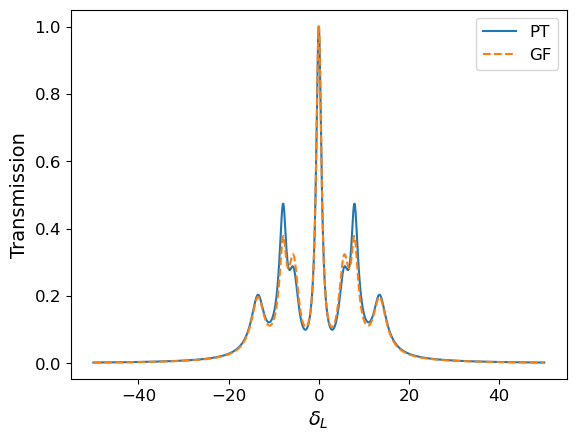

In [25]:
# Plot for comparison
plt.plot(δL, sum_abs_val_sq_pt / sum_abs_val_sq_pt.max(), label='PT')
plt.plot(δL, sum_abs_val_sq_gf / sum_abs_val_sq_gf.max(), '--', label='GF')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

As I mentioned before, this isn't exactly what we're looking for.  We're more interested in the individual overlaps of the transfer function, but we can't really get those in the perturbation theory.  So this calculation was mostly just to check against something we can calculate using perturbation theory.

Text(0.5, 1.0, '$|1,0,0\\rangle$')

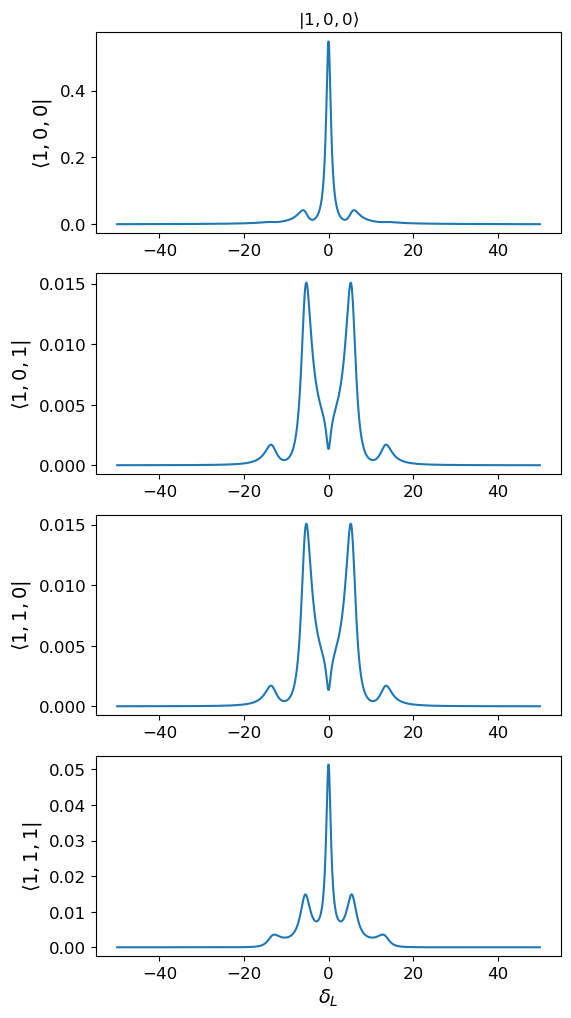

In [26]:
fig = plt.figure(1, figsize=(6,12))
ax = fig.subplots(4)
ylabels = ["$\\langle1,0,0|$",
           "$\\langle1,0,1|$",
          "$\\langle1,1,0|$",
          "$\\langle1,1,1|$"]
for i in range(len(gf_cav_vecs)):
    ax[i].plot(δL, np.abs(gf_ovlps[i][0]) ** 2)
    ax[i].set_ylabel(ylabels[i])
ax[3].set_xlabel("$\\delta_L$")
ax[0].set_title("$|1,0,0\\rangle$")

Text(0.5, 1.0, '$|1,0,1\\rangle$')

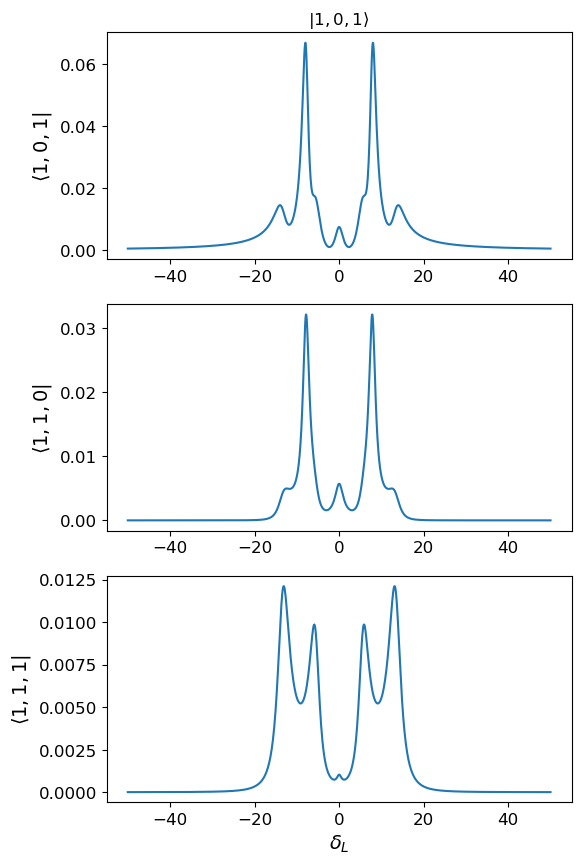

In [27]:
fig = plt.figure(1, figsize=(6,10))
ax = fig.subplots(3)
ylabels = ["$\\langle1,0,1|$",
           "$\\langle1,1,0|$",
          "$\\langle1,1,1|$"]
for i in range(1,len(gf_cav_vecs)):
    ax[i-1].plot(δL, np.abs(gf_ovlps[i][1]) ** 2)
    ax[i-1].set_ylabel(ylabels[i-1])
ax[-1].set_xlabel("$\\delta_L$")
ax[0].set_title("$|1,0,1\\rangle$")

Text(0.5, 1.0, '$|1,1,0\\rangle$')

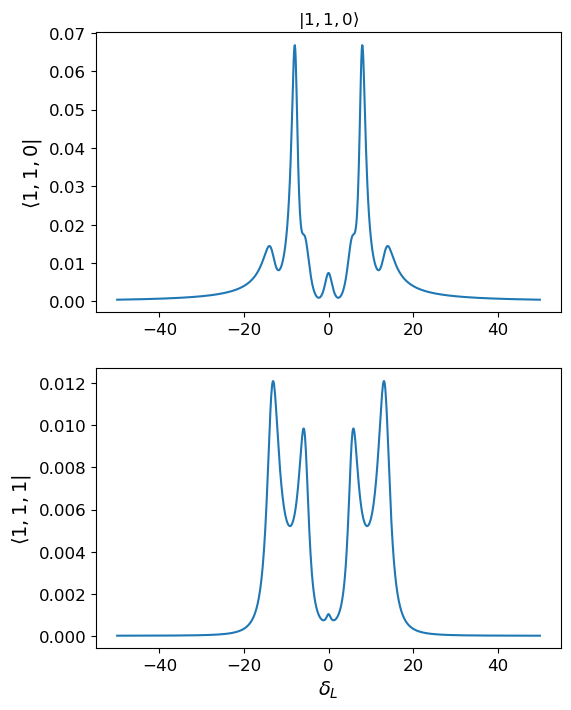

In [28]:
fig = plt.figure(1, figsize=(6,8))
ax = fig.subplots(2)
ylabels = ["$\\langle1,1,0|$",
          "$\\langle1,1,1|$"]
for i in range(2,len(gf_cav_vecs)):
    ax[i-2].plot(δL, np.abs(gf_ovlps[i][2]) ** 2)
    ax[i-2].set_ylabel(ylabels[i-2])
ax[-1].set_xlabel("$\\delta_L$")
ax[0].set_title("$|1,1,0\\rangle$")

Text(0.5, 1.0, '$|1,1,1\\rangle$')

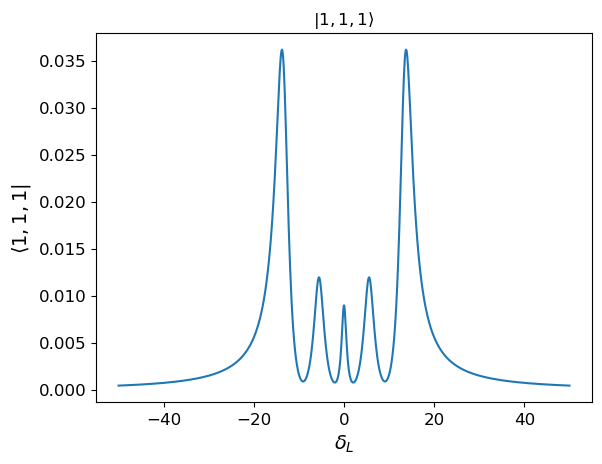

In [29]:
fig = plt.figure(1)
ax = fig.subplots(1)
ylabels = ["$\\langle1,1,1|$"]
for i in range(3,len(gf_cav_vecs)):
    ax.plot(δL, np.abs(gf_ovlps[i][3]) ** 2)
    ax.set_ylabel(ylabels[i-3])
ax.set_xlabel("$\\delta_L$")
ax.set_title("$|1,1,1\\rangle$")